## 1. Učitavanje biblioteka

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import joblib
import os

## 2. Učitavanje i pregled podataka

In [10]:
df_train = pd.read_csv('raw_data/application_train.csv')
df_test = pd.read_csv('raw_data/application_test.csv')

print(f"Trening: {df_train.shape}, Test: {df_test.shape}")
print(f"\nCiljna promenljiva:")
print(df_train['TARGET'].value_counts(normalize=True))

Trening: (307511, 122), Test: (48744, 121)

Ciljna promenljiva:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [11]:
df_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
df_train.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [13]:
print(df_train.dtypes.value_counts())
print(f"\nNedostajuce: {df_train.isnull().sum().sum()} ukupno, {(df_train.isnull().sum() > 0).sum()} kolona")

float64    65
int64      41
str        16
Name: count, dtype: int64

Nedostajuce: 9152465 ukupno, 67 kolona


In [14]:
# procenat nedostajucih vrednosti po koloni
missing_pct = (df_train.isnull().sum() / len(df_train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
print(f"Top 20 kolona sa nedostajucim vrednostima:")
print(missing_pct.head(20))

Top 20 kolona sa nedostajucim vrednostima:
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64


## 3. Vizualizacija podataka

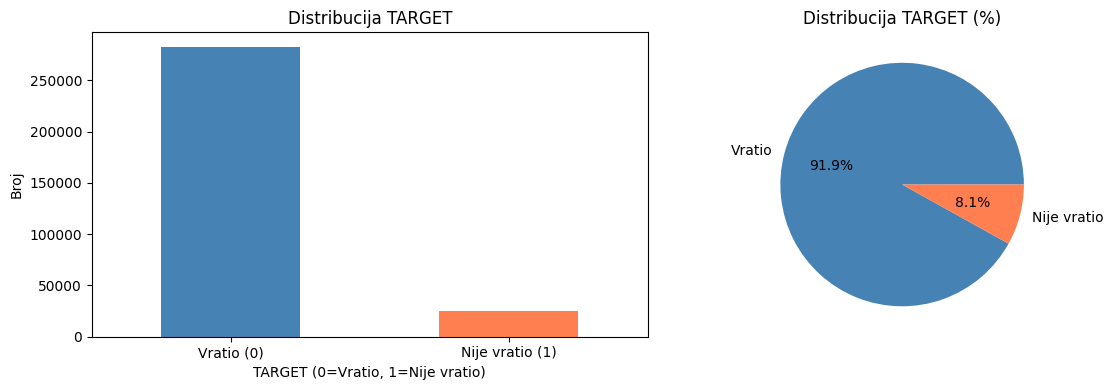


Napomena: Dataset je nebalansiran - vecina kredita je vracena (TARGET=0)


In [15]:
# distribucija ciljne promenljive
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_train['TARGET'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Distribucija TARGET')
axes[0].set_xlabel('TARGET (0=Vratio, 1=Nije vratio)')
axes[0].set_ylabel('Broj')
axes[0].set_xticklabels(['Vratio (0)', 'Nije vratio (1)'], rotation=0)

df_train['TARGET'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                        colors=['steelblue', 'coral'],
                                        labels=['Vratio', 'Nije vratio'])
axes[1].set_title('Distribucija TARGET (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNapomena: Dataset je nebalansiran - vecina kredita je vracena (TARGET=0)")

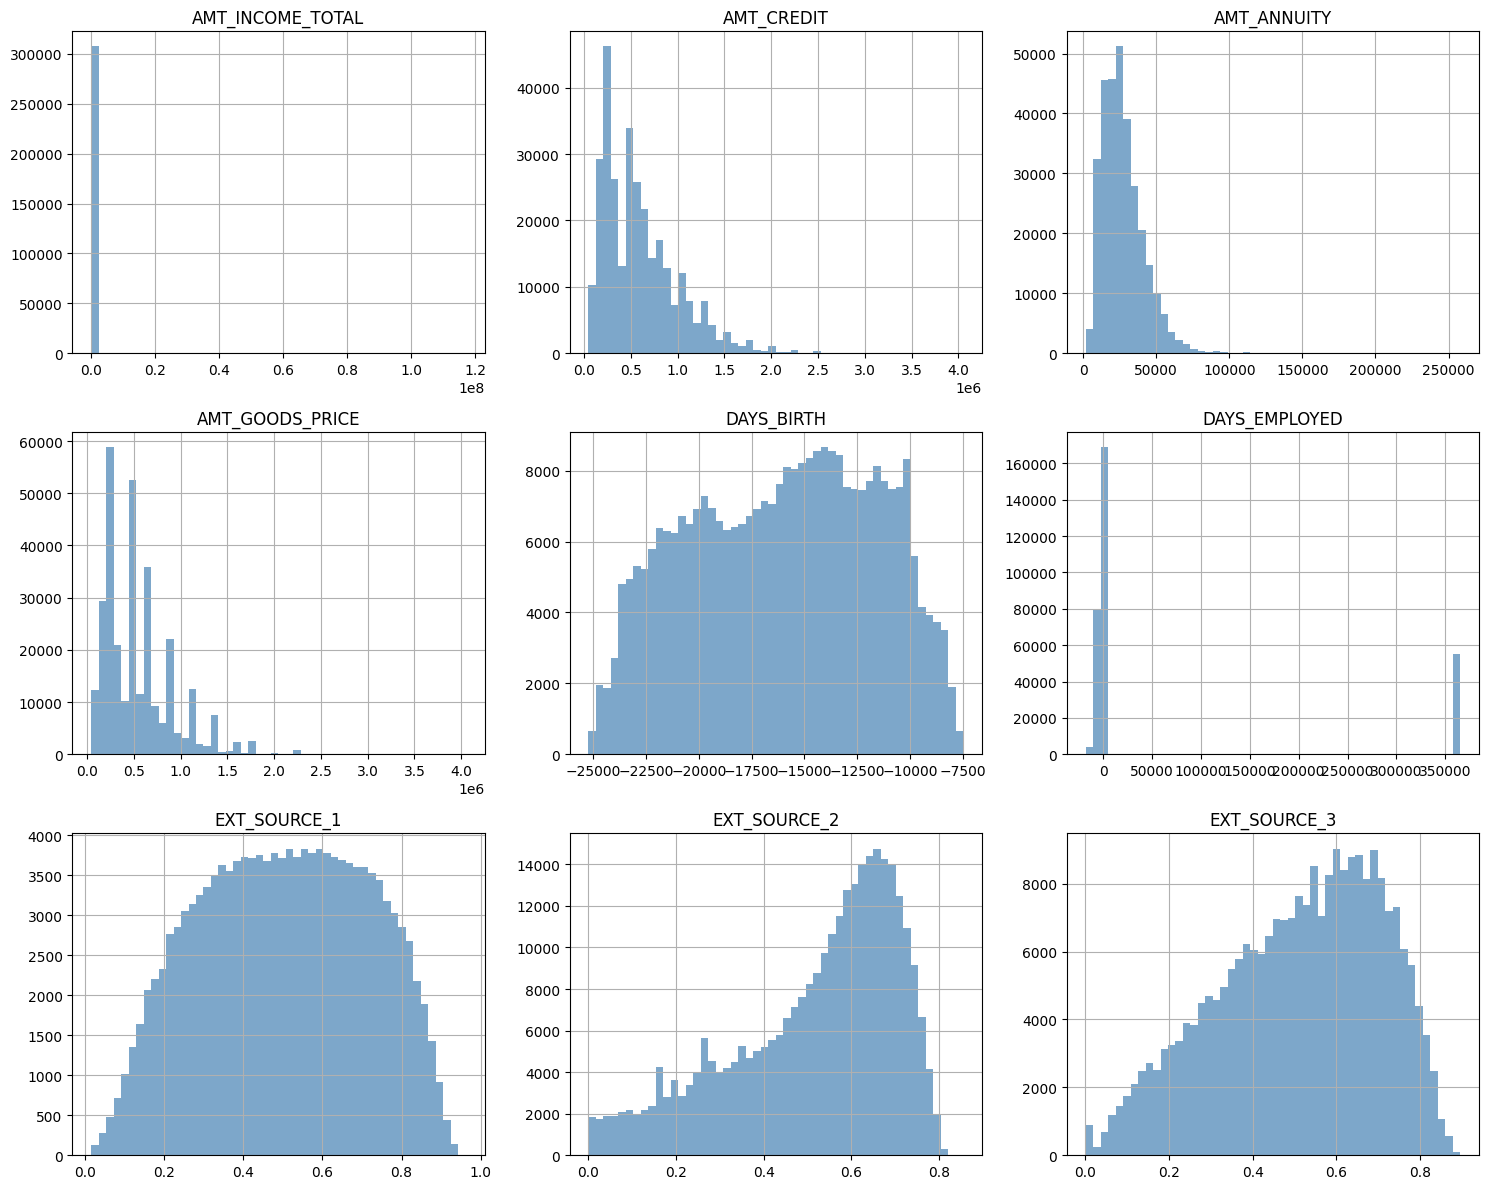

In [16]:
# distribucija numerickih atributa
numeric_cols = df_train.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['SK_ID_CURR', 'TARGET']]

# bitni numericki atributi za vizualizaciju
important_numeric = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
                     'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(important_numeric):
    if col in df_train.columns:
        df_train[col].hist(bins=50, ax=axes[i], color='steelblue', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

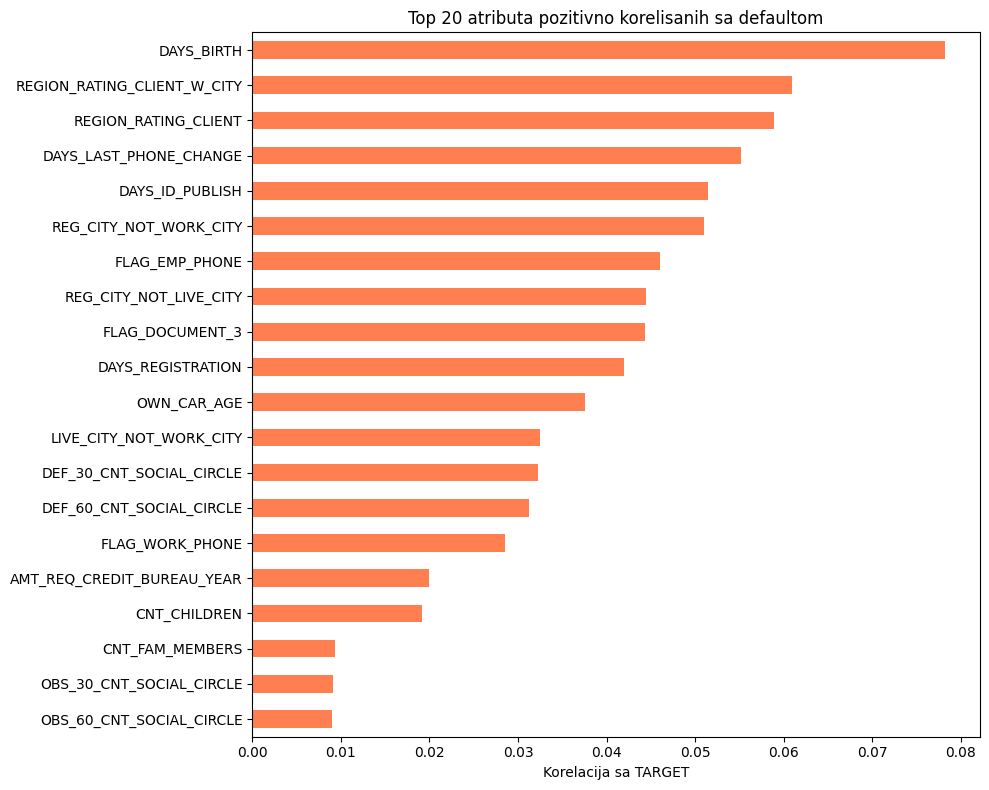

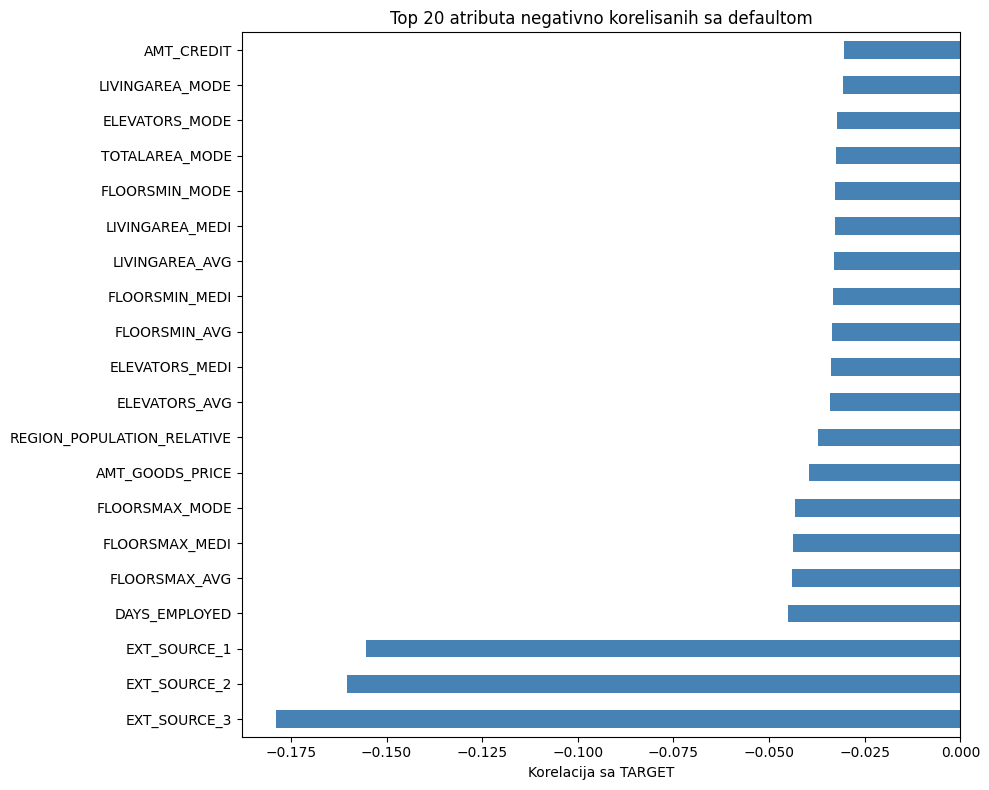

In [17]:
# korelacija sa ciljnom promenljivom
correlations = df_train[numeric_cols + ['TARGET']].corr()['TARGET'].drop('TARGET').sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
correlations.tail(20).plot(kind='barh', ax=ax, color='coral')
ax.set_title('Top 20 atributa pozitivno korelisanih sa defaultom')
ax.set_xlabel('Korelacija sa TARGET')
plt.tight_layout()
plt.savefig('positive_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
correlations.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 atributa negativno korelisanih sa defaultom')
ax.set_xlabel('Korelacija sa TARGET')
plt.tight_layout()
plt.savefig('negative_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Preprocesiranje podataka

In [18]:
def preprocess_data(df, is_train=True):
    """
    Preprocesiranje podataka:
    1. Obrada nedostajucih vrednosti
    2. Enkodiranje kategorickih promenljivih
    3. Uklanjanje anomalija
    """
    df = df.copy()
    
    # sacuvaj ID i target
    ids = df['SK_ID_CURR']
    if is_train:
        target = df['TARGET']
        df = df.drop(['SK_ID_CURR', 'TARGET'], axis=1)
    else:
        target = None
        df = df.drop(['SK_ID_CURR'], axis=1)
    
    # DAYS_EMPLOYED = 365243 znaci nezaposlen/penzioner
    df['DAYS_EMPLOYED_ANOMALY'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    
    # kategoricke i numericke kolone
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    
    print(f"Kategorickih kolona: {len(categorical_cols)}")
    print(f"Numerickih kolona: {len(numeric_cols)}")
    
    # label encoding za kategoricke
    le = LabelEncoder()
    for col in categorical_cols:
        df[col] = df[col].fillna('Missing')
        df[col] = le.fit_transform(df[col].astype(str))
    
    # popuni nedostajuce numericke sa medijanom
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())
    
    return df, ids, target

print("Preprocesiranje trening podataka...")
X, train_ids, y = preprocess_data(df_train, is_train=True)
print(f"\nDimenzije nakon preprocesiranja: {X.shape}")
print(f"Nedostajucih vrednosti: {X.isnull().sum().sum()}")

Preprocesiranje trening podataka...


Kategorickih kolona: 16
Numerickih kolona: 105

Dimenzije nakon preprocesiranja: (307511, 121)
Nedostajucih vrednosti: 0


In [19]:
# sacuvaj preprocesirane podatke
os.makedirs('preprocessed_data', exist_ok=True)

preprocessed_df = X.copy()
preprocessed_df['SK_ID_CURR'] = train_ids.values
preprocessed_df['TARGET'] = y.values
preprocessed_df.to_csv('preprocessed_data/application_train_preprocessed.csv', index=False)
print("Sacuvano u 'preprocessed_data/application_train_preprocessed.csv'")

Sacuvano u 'preprocessed_data/application_train_preprocessed.csv'


## 5. 2D/3D vizualizacija

In [20]:
# uzorak za vizualizaciju (ceo dataset je prevelik)
np.random.seed(42)
sample_size = 5000
sample_idx = np.random.choice(len(X), size=sample_size, replace=False)
X_sample = X.iloc[sample_idx]
y_sample = y.iloc[sample_idx]

# skaliranje za PCA/TSNE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_sample)

print(f"Velicina uzorka: {sample_size}")

Velicina uzorka: 5000


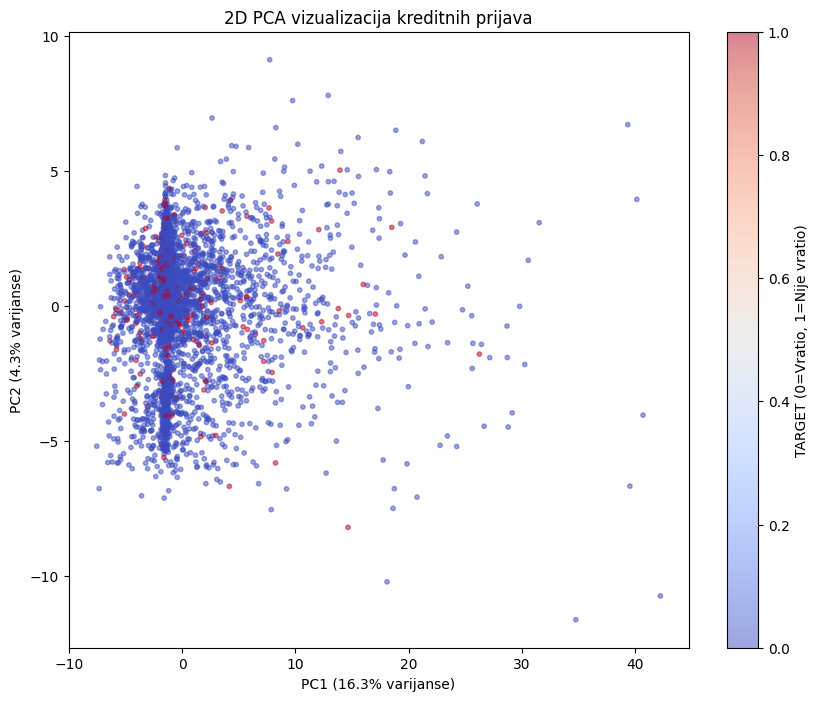

Ukupna objasjena varijansa sa 2 komponente: 20.6%


In [21]:
# 2D PCA vizualizacija
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], 
                     c=y_sample, cmap='coolwarm', alpha=0.5, s=10)
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% varijanse)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% varijanse)')
ax.set_title('2D PCA vizualizacija kreditnih prijava')
plt.colorbar(scatter, label='TARGET (0=Vratio, 1=Nije vratio)')
plt.savefig('pca_2d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ukupna objasjena varijansa sa 2 komponente: {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

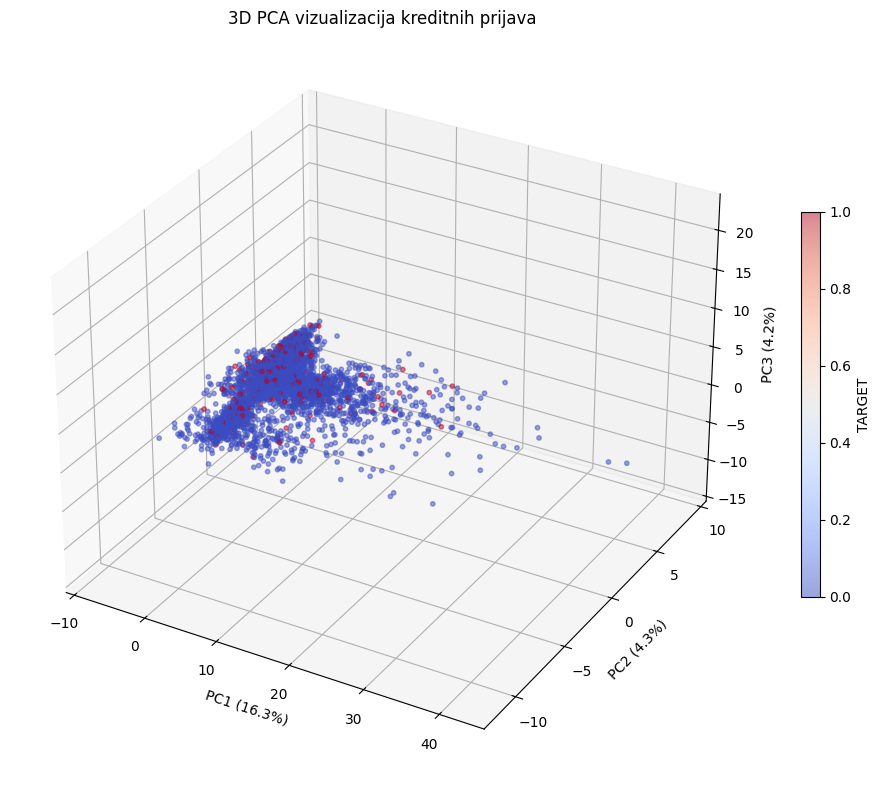

Ukupna objasjena varijansa sa 3 komponente: 24.8%


In [22]:
# 3D PCA vizualizacija
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
                     c=y_sample, cmap='coolwarm', alpha=0.5, s=10)
ax.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax.set_title('3D PCA vizualizacija kreditnih prijava')
plt.colorbar(scatter, label='TARGET', shrink=0.5)
plt.savefig('pca_3d_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Ukupna objasjena varijansa sa 3 komponente: {sum(pca_3d.explained_variance_ratio_)*100:.1f}%")

## 6. Podela podataka

In [23]:
# podela na trening i validacioni skup
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Trening skup: {X_train.shape}")
print(f"Validacioni skup: {X_val.shape}")
print(f"\nDistribucija u treningu: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Distribucija u validaciji: {y_val.value_counts(normalize=True).to_dict()}")

Trening skup: (246008, 121)
Validacioni skup: (61503, 121)

Distribucija u treningu: {0: 0.9192709180189262, 1: 0.08072908198107379}
Distribucija u validaciji: {0: 0.9192722306228964, 1: 0.08072776937710356}


In [24]:
# skaliranje atributa
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.joblib')

['models/scaler.joblib']

## 7. Treniranje klasifikacionih modela (5+ algoritama)

In [25]:
# modeli za treniranje
models = {
    '1. Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    '2. Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    '3. Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    '4. Gradient Boosting': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    '5. K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    '6. Naive Bayes': GaussianNB(),
    '7. AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42)
}

print(f"Broj modela: {len(models)}")

Broj modela: 7


In [26]:
# treniranje i evaluacija
results = []

for name, model in models.items():
    print(f"\nTreniranje {name}...")
    
    # skalirani podaci za modele bazirane na rastojanju
    if 'KNN' in name or 'Logistic' in name:
        X_data = X_train_scaled
        X_val_data = X_val_scaled
    else:
        X_data = X_train
        X_val_data = X_val
    
    model.fit(X_data, y_train)
    
    y_pred = model.predict(X_val_data)
    y_pred_proba = model.predict_proba(X_val_data)[:, 1]
    
    # kros-validacija (5-fold)
    cv_scores = cross_val_score(model, X_data, y_train, cv=5, scoring='roc_auc')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    # metrike
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc,
        'CV_Mean': cv_mean,
        'CV_Std': cv_std
    })
    
    # sacuvaj model
    model_filename = f"models/{name.replace(' ', '_').replace('.', '')}.joblib"
    joblib.dump(model, model_filename)
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")
    print(f"  CV ROC-AUC: {cv_mean:.4f} (+/- {cv_std:.4f})")

print("gotovo")


Treniranje 1. Logistic Regression...


  Accuracy: 0.9194
  ROC-AUC: 0.7473
  CV ROC-AUC: 0.7436 (+/- 0.0056)

Treniranje 2. Decision Tree...
  Accuracy: 0.9172
  ROC-AUC: 0.7114
  CV ROC-AUC: 0.7067 (+/- 0.0039)

Treniranje 3. Random Forest...
  Accuracy: 0.9193
  ROC-AUC: 0.7388
  CV ROC-AUC: 0.7348 (+/- 0.0049)

Treniranje 4. Gradient Boosting...
  Accuracy: 0.9195
  ROC-AUC: 0.7570
  CV ROC-AUC: 0.7539 (+/- 0.0052)

Treniranje 5. K-Nearest Neighbors...
  Accuracy: 0.9136
  ROC-AUC: 0.5542
  CV ROC-AUC: 0.5522 (+/- 0.0040)

Treniranje 6. Naive Bayes...
  Accuracy: 0.9129
  ROC-AUC: 0.6111
  CV ROC-AUC: 0.6113 (+/- 0.0035)

Treniranje 7. AdaBoost...
  Accuracy: 0.9195
  ROC-AUC: 0.7473
  CV ROC-AUC: 0.7425 (+/- 0.0055)
gotovo


## 8. Poredjenje modela

In [27]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('ROC-AUC', ascending=False)
results_df = results_df.reset_index(drop=True)

print(results_df.to_string(index=False))

results_df.to_csv('model_comparison_results.csv', index=False)

                 Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  CV_Mean   CV_Std
  4. Gradient Boosting  0.919451   0.528205 0.020745  0.039922 0.757032 0.753935 0.005199
           7. AdaBoost  0.919549   0.593407 0.010876  0.021361 0.747316 0.742546 0.005548
1. Logistic Regression  0.919435   0.552083 0.010675  0.020944 0.747291 0.743592 0.005625
      3. Random Forest  0.919272   0.000000 0.000000  0.000000 0.738779 0.734828 0.004864
      2. Decision Tree  0.917240   0.314540 0.021349  0.039985 0.711399 0.706665 0.003948
        6. Naive Bayes  0.912882   0.062361 0.005639  0.010344 0.611090 0.611268 0.003522
5. K-Nearest Neighbors  0.913565   0.170732 0.018328  0.033103 0.554178 0.552215 0.004012


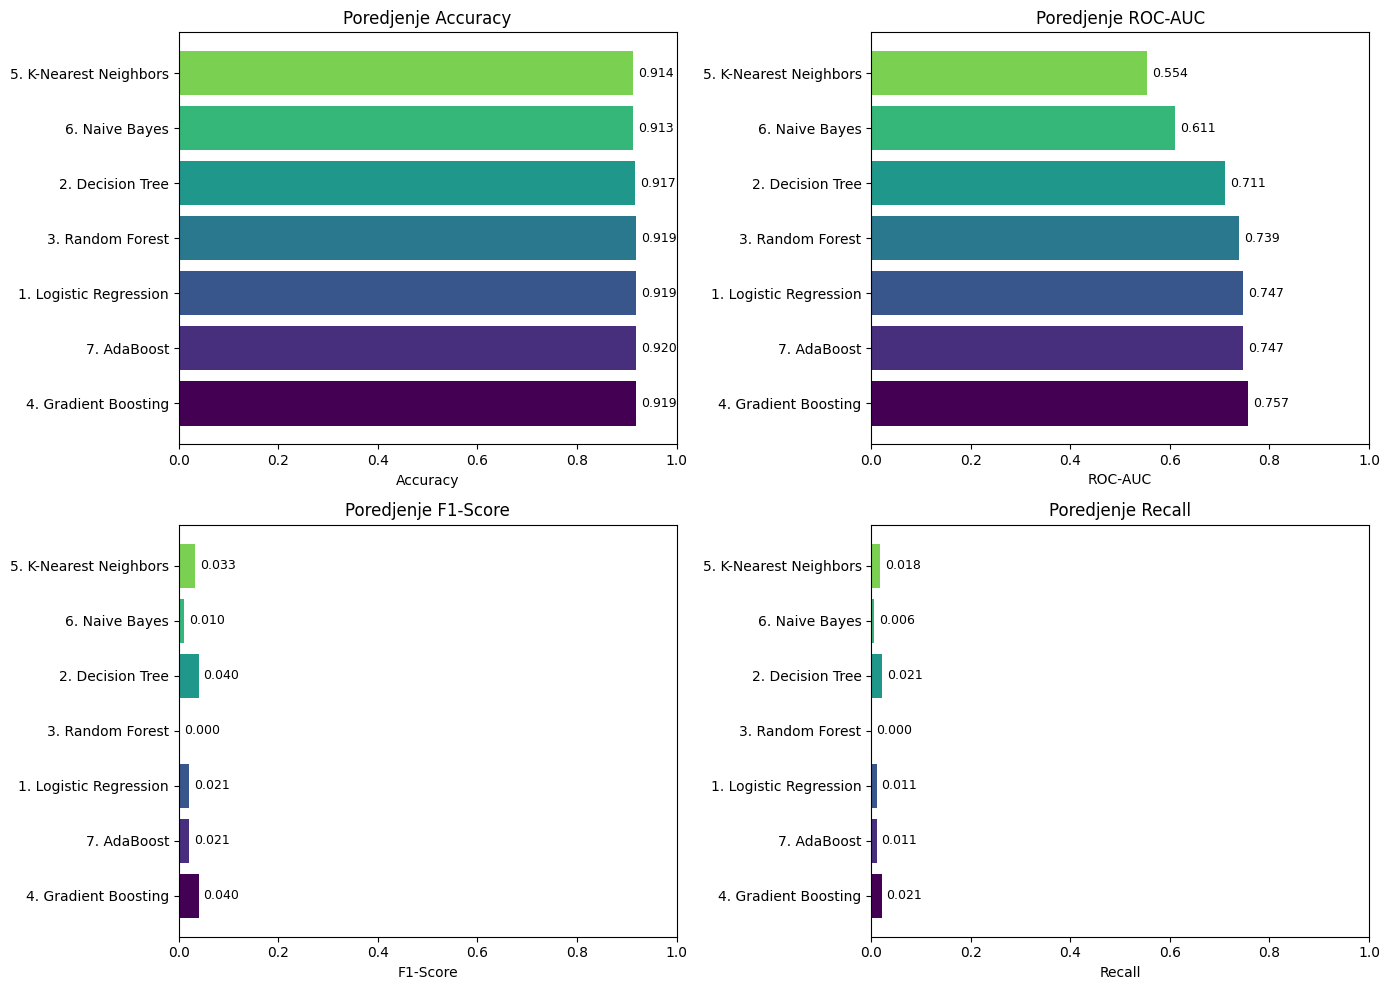

In [28]:
# vizualizacija poredjenja
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'ROC-AUC', 'F1-Score', 'Recall']
colors = plt.cm.viridis(np.linspace(0, 0.8, len(results_df)))

for ax, metric in zip(axes.flatten(), metrics):
    bars = ax.barh(results_df['Model'], results_df[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_title(f'Poredjenje {metric}')
    ax.set_xlim(0, 1)
    
    for bar, val in zip(bars, results_df[metric]):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

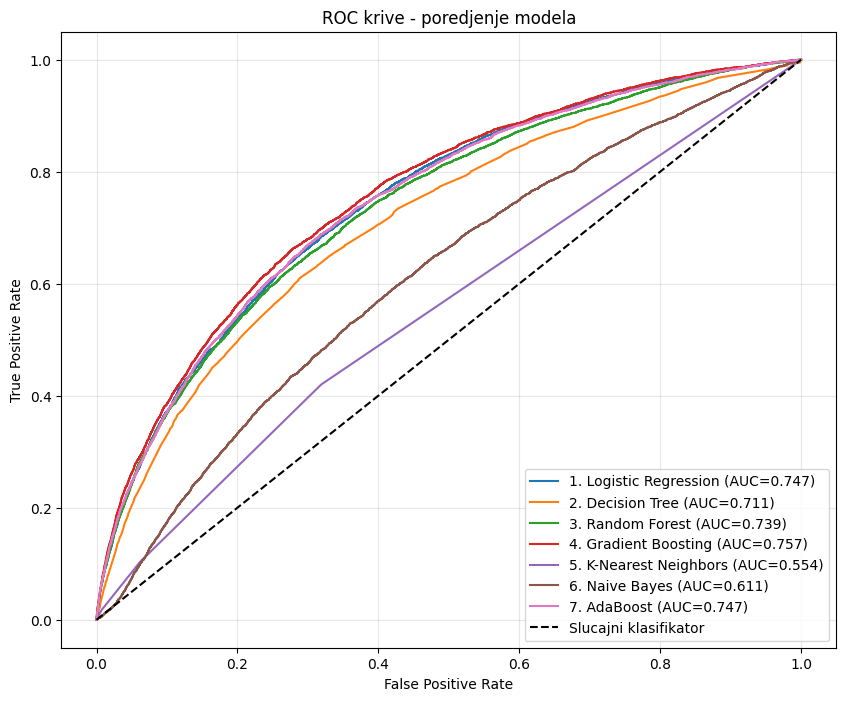

In [29]:
# ROC krive za sve modele
fig, ax = plt.subplots(figsize=(10, 8))

for name, model in models.items():
    if 'KNN' in name or 'Logistic' in name:
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
    else:
        y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
    auc = roc_auc_score(y_val, y_pred_proba)
    
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', label='Slucajni klasifikator')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC krive - poredjenje modela')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

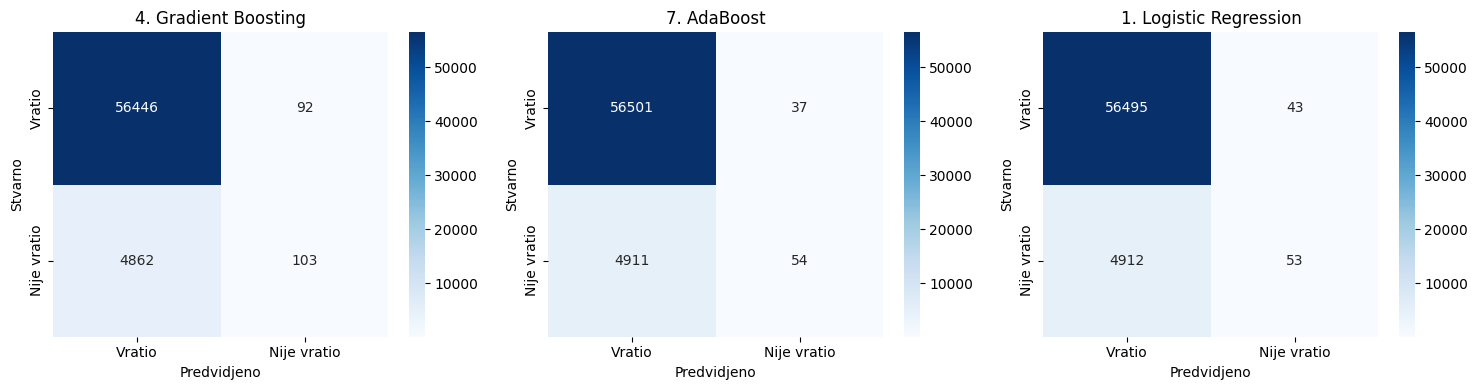

In [30]:
# matrice konfuzije za top 3 modela
top_3_models = results_df.head(3)['Model'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top_3_models):
    model = models[name]
    
    if 'KNN' in name or 'Logistic' in name:
        y_pred = model.predict(X_val_scaled)
    else:
        y_pred = model.predict(X_val)
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Vratio', 'Nije vratio'],
                yticklabels=['Vratio', 'Nije vratio'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predvidjeno')
    ax.set_ylabel('Stvarno')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Analiza vaznosti atributa

In [31]:
# vaznost atributa iz Random Forest
rf_model = models['3. Random Forest']
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Top 20 najvaznijih atributa (Random Forest):")
print(feature_importance.head(20).to_string(index=False))

Top 20 najvaznijih atributa (Random Forest):
                    Feature  Importance
               EXT_SOURCE_3    0.176837
               EXT_SOURCE_2    0.166858
               EXT_SOURCE_1    0.053677
              DAYS_EMPLOYED    0.041356
                 DAYS_BIRTH    0.035030
     DAYS_LAST_PHONE_CHANGE    0.021166
            AMT_GOODS_PRICE    0.020137
            DAYS_ID_PUBLISH    0.019072
        NAME_EDUCATION_TYPE    0.018836
                 AMT_CREDIT    0.017501
          DAYS_REGISTRATION    0.016825
                AMT_ANNUITY    0.016491
                CODE_GENDER    0.014207
 REGION_POPULATION_RELATIVE    0.010382
           AMT_INCOME_TOTAL    0.010109
           NAME_INCOME_TYPE    0.009924
    HOUR_APPR_PROCESS_START    0.009640
                OWN_CAR_AGE    0.009283
REGION_RATING_CLIENT_W_CITY    0.009187
          ORGANIZATION_TYPE    0.008515


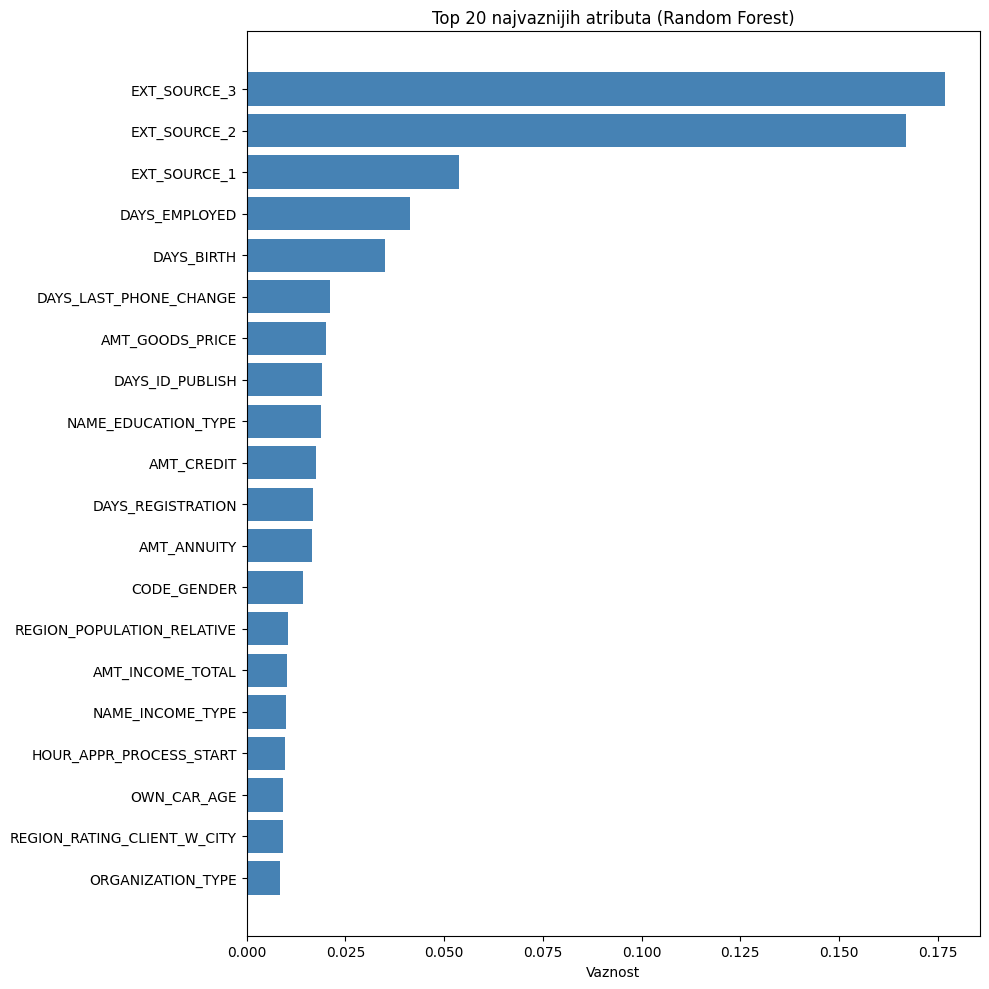

In [32]:
# grafik vaznosti atributa
fig, ax = plt.subplots(figsize=(10, 10))
top_20_features = feature_importance.head(20)
ax.barh(top_20_features['Feature'], top_20_features['Importance'], color='steelblue')
ax.set_xlabel('Vaznost')
ax.set_title('Top 20 najvaznijih atributa (Random Forest)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Modeli sa redukovanim atributima

In [33]:
# izbor top atributa na osnovu vaznosti
top_features = feature_importance.head(20)['Feature'].tolist()

X_train_reduced = X_train[top_features]
X_val_reduced = X_val[top_features]

scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_val_reduced_scaled = scaler_reduced.transform(X_val_reduced)

print(f"Redukovani skup: {len(top_features)} atributa")
print(f"Atributi: {top_features}")

Redukovani skup: 20 atributa
Atributi: ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'DAYS_EMPLOYED', 'DAYS_BIRTH', 'DAYS_LAST_PHONE_CHANGE', 'AMT_GOODS_PRICE', 'DAYS_ID_PUBLISH', 'NAME_EDUCATION_TYPE', 'AMT_CREDIT', 'DAYS_REGISTRATION', 'AMT_ANNUITY', 'CODE_GENDER', 'REGION_POPULATION_RELATIVE', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'HOUR_APPR_PROCESS_START', 'OWN_CAR_AGE', 'REGION_RATING_CLIENT_W_CITY', 'ORGANIZATION_TYPE']


In [34]:
# modeli sa redukovanim atributima
models_reduced = {
    '1. Logistic Regression (Reduced)': LogisticRegression(max_iter=1000, random_state=42),
    '2. Decision Tree (Reduced)': DecisionTreeClassifier(max_depth=10, random_state=42),
    '3. Random Forest (Reduced)': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    '4. Gradient Boosting (Reduced)': GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42),
    '5. K-Nearest Neighbors (Reduced)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
}

results_reduced = []

for name, model in models_reduced.items():
    print(f"\nTreniranje {name}...")
    
    if 'KNN' in name or 'Logistic' in name:
        model.fit(X_train_reduced_scaled, y_train)
        y_pred = model.predict(X_val_reduced_scaled)
        y_pred_proba = model.predict_proba(X_val_reduced_scaled)[:, 1]
    else:
        model.fit(X_train_reduced, y_train)
        y_pred = model.predict(X_val_reduced)
        y_pred_proba = model.predict_proba(X_val_reduced)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    
    results_reduced.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    })
    
    # sacuvaj model
    model_filename = f"models/{name.replace(' ', '_').replace('.', '').replace('(', '').replace(')', '')}.joblib"
    joblib.dump(model, model_filename)
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  ROC-AUC: {roc_auc:.4f}")

print("gotovo")


Treniranje 1. Logistic Regression (Reduced)...
  Accuracy: 0.9194
  ROC-AUC: 0.7396

Treniranje 2. Decision Tree (Reduced)...
  Accuracy: 0.9175
  ROC-AUC: 0.7113

Treniranje 3. Random Forest (Reduced)...
  Accuracy: 0.9193
  ROC-AUC: 0.7449

Treniranje 4. Gradient Boosting (Reduced)...
  Accuracy: 0.9194
  ROC-AUC: 0.7548

Treniranje 5. K-Nearest Neighbors (Reduced)...
  Accuracy: 0.9136
  ROC-AUC: 0.5542
gotovo


In [35]:
# poredjenje svih vs redukovanih atributa
results_reduced_df = pd.DataFrame(results_reduced)

print(results_reduced_df.sort_values('ROC-AUC', ascending=False).to_string(index=False))

results_reduced_df.to_csv('model_comparison_reduced_features.csv', index=False)

                           Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
  4. Gradient Boosting (Reduced)  0.919435   0.525000 0.021148  0.040658 0.754782
      3. Random Forest (Reduced)  0.919305   1.000000 0.000403  0.000805 0.744855
1. Logistic Regression (Reduced)  0.919402   0.560606 0.007452  0.014709 0.739633
      2. Decision Tree (Reduced)  0.917467   0.320388 0.019940  0.037543 0.711270
5. K-Nearest Neighbors (Reduced)  0.913565   0.170732 0.018328  0.033103 0.554178


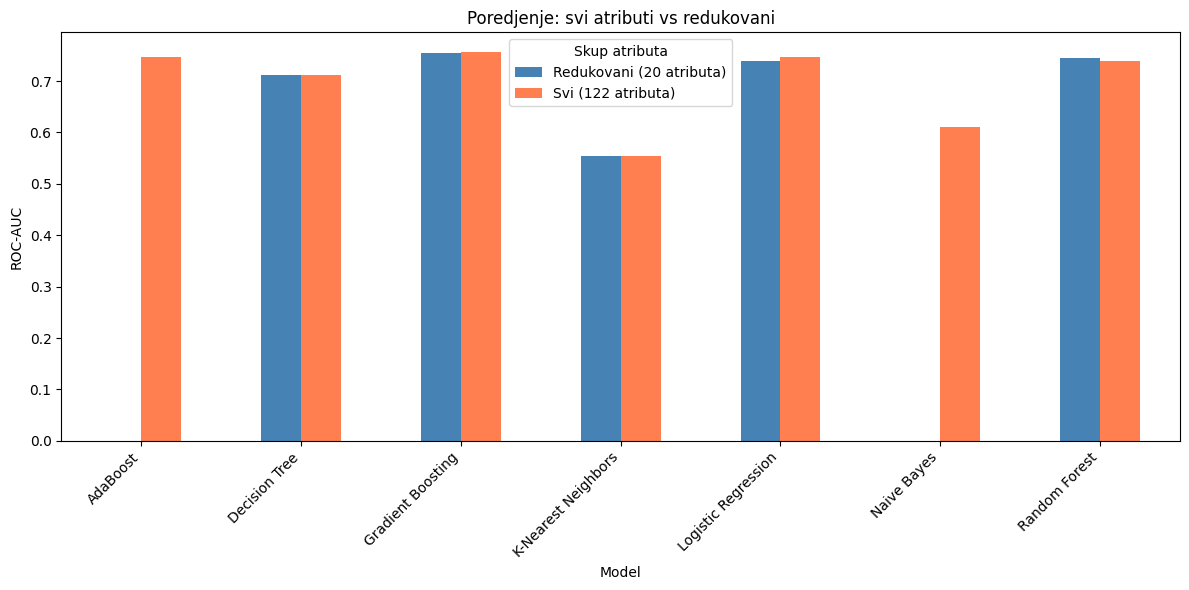

In [36]:
# poredjenje performansi
comparison_data = []
for i, row in results_df.iterrows():
    model_base = row['Model'].split('. ')[1] if '. ' in row['Model'] else row['Model']
    comparison_data.append({
        'Model': model_base,
        'Feature Set': 'Svi (122 atributa)',
        'ROC-AUC': row['ROC-AUC']
    })

for i, row in results_reduced_df.iterrows():
    model_base = row['Model'].replace(' (Reduced)', '').split('. ')[1] if '. ' in row['Model'] else row['Model']
    comparison_data.append({
        'Model': model_base,
        'Feature Set': 'Redukovani (20 atributa)',
        'ROC-AUC': row['ROC-AUC']
    })

comparison_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(12, 6))
comparison_pivot = comparison_df.pivot(index='Model', columns='Feature Set', values='ROC-AUC')
comparison_pivot.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_xlabel('Model')
ax.set_ylabel('ROC-AUC')
ax.set_title('Poredjenje: svi atributi vs redukovani')
ax.legend(title='Skup atributa')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.savefig('full_vs_reduced_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Rezime i zakljucci

In [37]:
best_model = results_df.iloc[0]
print(f"Dataset: {df_train.shape[0]} uzoraka, {df_train.shape[1]} atributa")
print(f"Distribucija: {(y == 0).sum()} vraceno ({(y == 0).mean()*100:.1f}%), {(y == 1).sum()} default ({(y == 1).mean()*100:.1f}%)")
print(f"\nNajbolji model: {best_model['Model']}")
print(f"   - ROC-AUC: {best_model['ROC-AUC']:.4f}")
print(f"   - Accuracy: {best_model['Accuracy']:.4f}")
print(f"   - F1-Score: {best_model['F1-Score']:.4f}")

print(f"\nKljucni uvidi:")
print("   1. Dataset je nebalansiran (~92% vraceno, ~8% default)")
print("   2. EXT_SOURCE atributi su najprediktivniji")
print("   3. Ansambl metode (Random Forest, Gradient Boosting) daju najbolje rezultate")
print("   4. Modeli sa redukovanim atributima imaju slicne performanse")

Dataset: 307511 uzoraka, 122 atributa
Distribucija: 282686 vraceno (91.9%), 24825 default (8.1%)

Najbolji model: 4. Gradient Boosting
   - ROC-AUC: 0.7570
   - Accuracy: 0.9195
   - F1-Score: 0.0399

Kljucni uvidi:
   1. Dataset je nebalansiran (~92% vraceno, ~8% default)
   2. EXT_SOURCE atributi su najprediktivniji
   3. Ansambl metode (Random Forest, Gradient Boosting) daju najbolje rezultate
   4. Modeli sa redukovanim atributima imaju slicne performanse


In [38]:
# sacuvani modeli
print("Sacuvani modeli:")
for f in os.listdir('models'):
    print(f"  - models/{f}")

Sacuvani modeli:
  - models/8_XGBoost.joblib
  - models/scaler_advanced.joblib
  - models/advanced_6_Naive_Bayes.joblib
  - models/9_LightGBM.joblib
  - models/best_lightgbm_params.csv
  - models/pca_clustering.joblib
  - models/5_K-Nearest_Neighbors.joblib
  - models/feature_importance_boosting.png
  - models/advanced_7_AdaBoost.joblib
  - models/2_Decision_Tree.joblib
  - models/2_Decision_Tree_Reduced.joblib
  - models/tsne_visualization.png
  - models/scaler_optimized.joblib
  - models/learning_curve_lightgbm.png
  - models/5_K-Nearest_Neighbors_Reduced.joblib
  - models/pca_2d_visualization.png
  - models/4_Gradient_Boosting.joblib
  - models/3_Random_Forest_Reduced.joblib
  - models/advanced_2_Decision_Tree.joblib
  - models/scaler_boosting.joblib
  - models/kmeans_vs_target.png
  - models/scaler_clustering.joblib
  - models/advanced_4_Gradient_Boosting.joblib
  - models/pca_3d_visualization.png
  - models/6_Naive_Bayes.joblib
  - models/advanced_5_K-Nearest_Neighbors.joblib
  - 